In [1]:
from experiments.Model_Picker.picker_utils import find_fixed_point, compute_jacobian, analyze_jacobian_structure, eigen_analysis, analyze_eigenspectrum
import numpy as np
from hbnm.io import Data
from hbnm.bnm import Bnm


In [2]:
"""
Set directories
"""
input_dir = "/home/frank/HBNM/data/"
output_dir = "/home/frank/HBNM/outputs/"

"""
Load data
"""
data = Data(input_dir, output_dir)
sc, hmap, fc_obj = data.load_demirtas_neuron_2019_data() 

fin = data.load('demirtas_neuron_2019.hdf5', from_output=False)
theta_heterogeneous = fin['apprx_posterior_heterogeneous'][:]
theta_homogeneous = fin['apprx_posterior_homogeneous'][:]
fin.close()


In [3]:
# Homogeneous model

homogeneous = Bnm(sc)
homogeneous.set('w_EI', theta_homogeneous[0,0])
homogeneous.set('w_EE', theta_homogeneous[1,0])
homogeneous.set('G', theta_homogeneous[2,0])
# homogeneous.moments_method()

In [4]:
# Heterogeneous model

heterogeneous = Bnm(sc, gradient=hmap)
heterogeneous.set('w_EI', (theta_heterogeneous[0,0], theta_heterogeneous[1,0]))
heterogeneous.set('w_EE', (theta_heterogeneous[2,0], theta_heterogeneous[3,0]))
heterogeneous.set('G', theta_heterogeneous[4,0])
# heterogeneous.moments_method()

In [5]:
import matplotlib.pyplot as plt

# ============================================================================
# HOMOGENEOUS MODEL ANALYSIS
# ============================================================================

print("=== HOMOGENEOUS MODEL ANALYSIS ===")

# Find fixed point and compute Jacobian (without BOLD)
fixed_point_homo = find_fixed_point(homogeneous)
jacobian_homo = compute_jacobian(homogeneous, include_bold=False)

# Perform eigenanalysis
eigen_results_homo = eigen_analysis(jacobian_homo)

# Analyze eigenspectrum
analyze_eigenspectrum(eigen_results_homo, verbose=True)


=== HOMOGENEOUS MODEL ANALYSIS ===

=== EIGENSPECTRUM ANALYSIS ===
Total eigenvalues: 360
Real eigenvalues: 0
Complex eigenvalues: 360 (180 conjugate pairs)

Stability analysis:
  Positive real parts: 0
  Negative real parts: 360
  Near-zero real parts: 0
  System is: STABLE

Dominant eigenvalue: -6.745305+69.138343j
  Dominant frequency: 11.004 Hz
Spectral radius: 253.976412


{'n_total': 360,
 'n_real': np.int64(0),
 'n_complex': np.int64(360),
 'n_positive_real': np.int64(0),
 'n_negative_real': np.int64(360),
 'n_zero_real': np.int64(0),
 'stability': 'stable',
 'n_unstable_modes': np.int64(0),
 'dominant_eigenvalue': np.complex128(-6.745305248016254+69.13834279960122j),
 'spectral_radius': np.float64(253.97641213998793)}

In [6]:
# ============================================================================
# HETEROGENEOUS MODEL ANALYSIS  
# ============================================================================

print("\n=== HETEROGENEOUS MODEL ANALYSIS ===")

# Find fixed point and compute Jacobian (without BOLD)
fixed_point_hetero = find_fixed_point(heterogeneous)
jacobian_hetero = compute_jacobian(heterogeneous, include_bold=False)

# Perform eigenanalysis
eigen_results_hetero = eigen_analysis(jacobian_hetero)

# Analyze eigenspectrum
analyze_eigenspectrum(eigen_results_hetero, verbose=True)



=== HETEROGENEOUS MODEL ANALYSIS ===

=== EIGENSPECTRUM ANALYSIS ===
Total eigenvalues: 360
Real eigenvalues: 360
Complex eigenvalues: 0

Stability analysis:
  Positive real parts: 0
  Negative real parts: 360
  Near-zero real parts: 0
  System is: STABLE

Dominant eigenvalue: -0.040321
Spectral radius: 266.443047


{'n_total': 360,
 'n_real': np.int64(360),
 'n_complex': np.int64(0),
 'n_positive_real': np.int64(0),
 'n_negative_real': np.int64(360),
 'n_zero_real': np.int64(0),
 'stability': 'stable',
 'n_unstable_modes': np.int64(0),
 'dominant_eigenvalue': np.float64(-0.04032104132009332),
 'spectral_radius': np.float64(266.443047330293)}

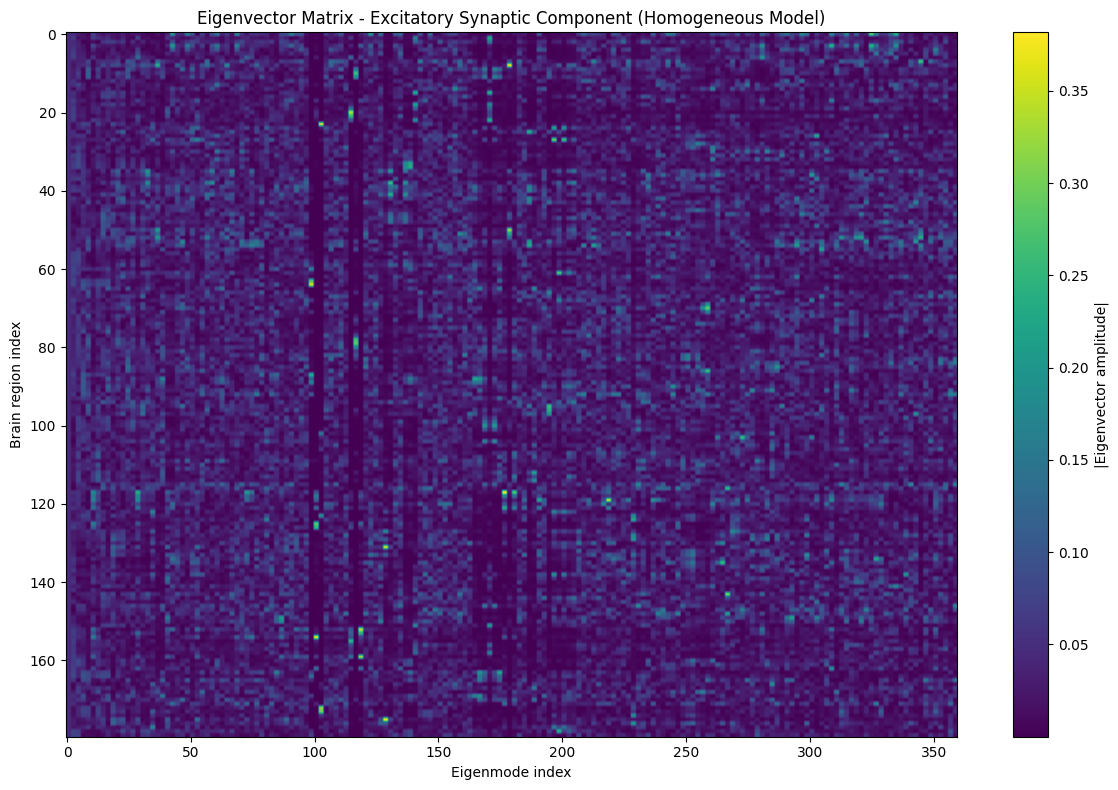

Homogeneous model - Excitatory eigenvector matrix shape: (180, 360)
Number of regions: 180


In [7]:
# ============================================================================
# EIGENVECTOR MATRIX PLOTTING - HOMOGENEOUS MODEL
# ============================================================================

# Extract eigenvectors and get number of regions
eigenvectors_homo = eigen_results_homo['eigenvectors']
n_regions = len(fixed_point_homo['S_E'])

# For synaptic-only system: first n_regions correspond to S_E (excitatory synaptic component)
eigenvectors_excitatory_homo = eigenvectors_homo[:n_regions, :]

# Plot eigenvector matrix for excitatory component
plt.figure(figsize=(12, 8))
plt.imshow(np.abs(eigenvectors_excitatory_homo), cmap='viridis', aspect='auto')
plt.colorbar(label='|Eigenvector amplitude|')
plt.title('Eigenvector Matrix - Excitatory Synaptic Component (Homogeneous Model)')
plt.xlabel('Eigenmode index')
plt.ylabel('Brain region index')
plt.tight_layout()
plt.show()

print(f"Homogeneous model - Excitatory eigenvector matrix shape: {eigenvectors_excitatory_homo.shape}")
print(f"Number of regions: {n_regions}")


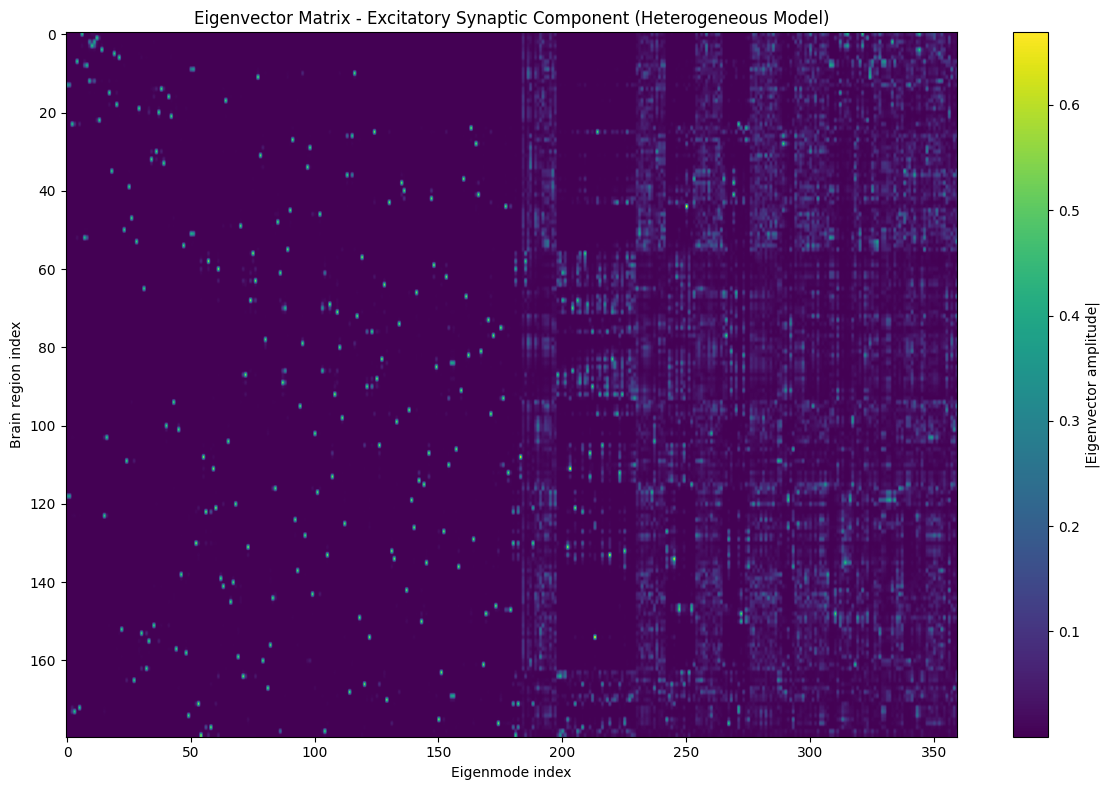

Heterogeneous model - Excitatory eigenvector matrix shape: (180, 360)
Number of regions: 180


In [8]:
# ============================================================================
# EIGENVECTOR MATRIX PLOTTING - HETEROGENEOUS MODEL
# ============================================================================

# Extract eigenvectors and get number of regions
eigenvectors_hetero = eigen_results_hetero['eigenvectors']
n_regions_hetero = len(fixed_point_hetero['S_E'])

# For synaptic-only system: first n_regions correspond to S_E (excitatory synaptic component)
eigenvectors_excitatory_hetero = eigenvectors_hetero[:n_regions_hetero, :]

# Plot eigenvector matrix for excitatory component
plt.figure(figsize=(12, 8))
plt.imshow(np.abs(eigenvectors_excitatory_hetero), cmap='viridis', aspect='auto')
plt.colorbar(label='|Eigenvector amplitude|')
plt.title('Eigenvector Matrix - Excitatory Synaptic Component (Heterogeneous Model)')
plt.xlabel('Eigenmode index')
plt.ylabel('Brain region index')
plt.tight_layout()
plt.show()

print(f"Heterogeneous model - Excitatory eigenvector matrix shape: {eigenvectors_excitatory_hetero.shape}")
print(f"Number of regions: {n_regions_hetero}")


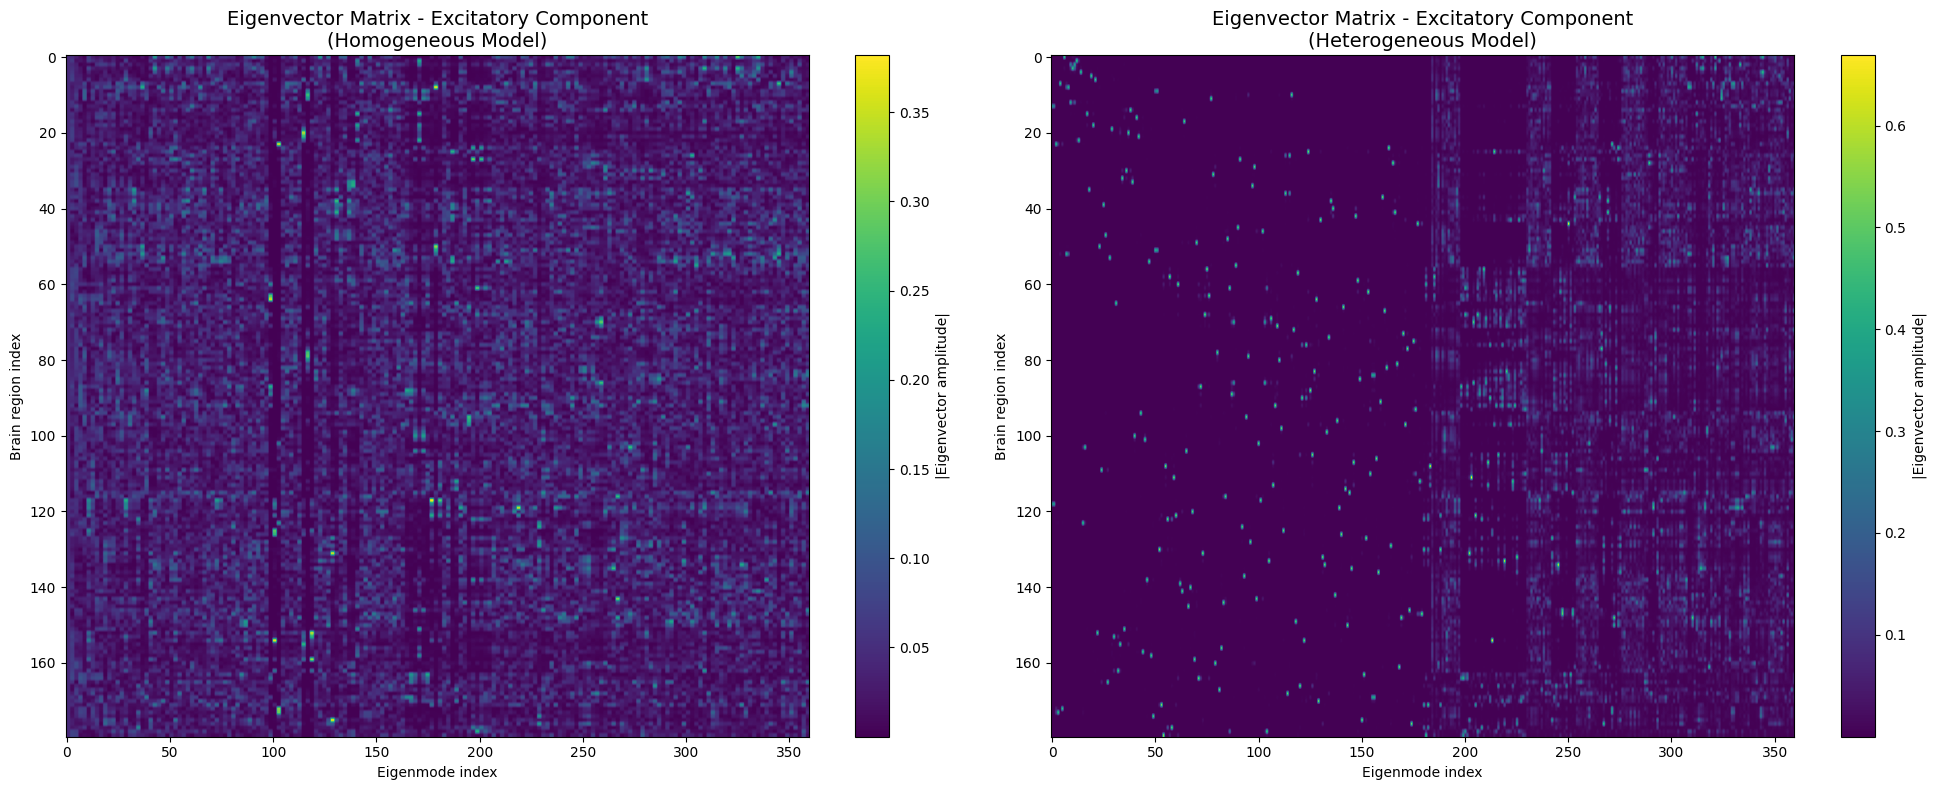

=== COMPARISON SUMMARY ===
Homogeneous model: (180, 360) eigenvector matrix
Heterogeneous model: (180, 360) eigenvector matrix
Both models have 180 brain regions


In [9]:
# ============================================================================
# COMPARISON PLOT - BOTH MODELS SIDE BY SIDE
# ============================================================================

# Create side-by-side comparison plot
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Homogeneous model plot
im1 = axes[0].imshow(np.abs(eigenvectors_excitatory_homo), cmap='viridis', aspect='auto')
axes[0].set_title('Eigenvector Matrix - Excitatory Component\n(Homogeneous Model)', fontsize=14)
axes[0].set_xlabel('Eigenmode index')
axes[0].set_ylabel('Brain region index')
plt.colorbar(im1, ax=axes[0], label='|Eigenvector amplitude|')

# Heterogeneous model plot
im2 = axes[1].imshow(np.abs(eigenvectors_excitatory_hetero), cmap='viridis', aspect='auto')
axes[1].set_title('Eigenvector Matrix - Excitatory Component\n(Heterogeneous Model)', fontsize=14)
axes[1].set_xlabel('Eigenmode index')
axes[1].set_ylabel('Brain region index')
plt.colorbar(im2, ax=axes[1], label='|Eigenvector amplitude|')

plt.tight_layout()
plt.show()

# Print comparison summary
print("=== COMPARISON SUMMARY ===")
print(f"Homogeneous model: {eigenvectors_excitatory_homo.shape} eigenvector matrix")
print(f"Heterogeneous model: {eigenvectors_excitatory_hetero.shape} eigenvector matrix")
print(f"Both models have {n_regions} brain regions")


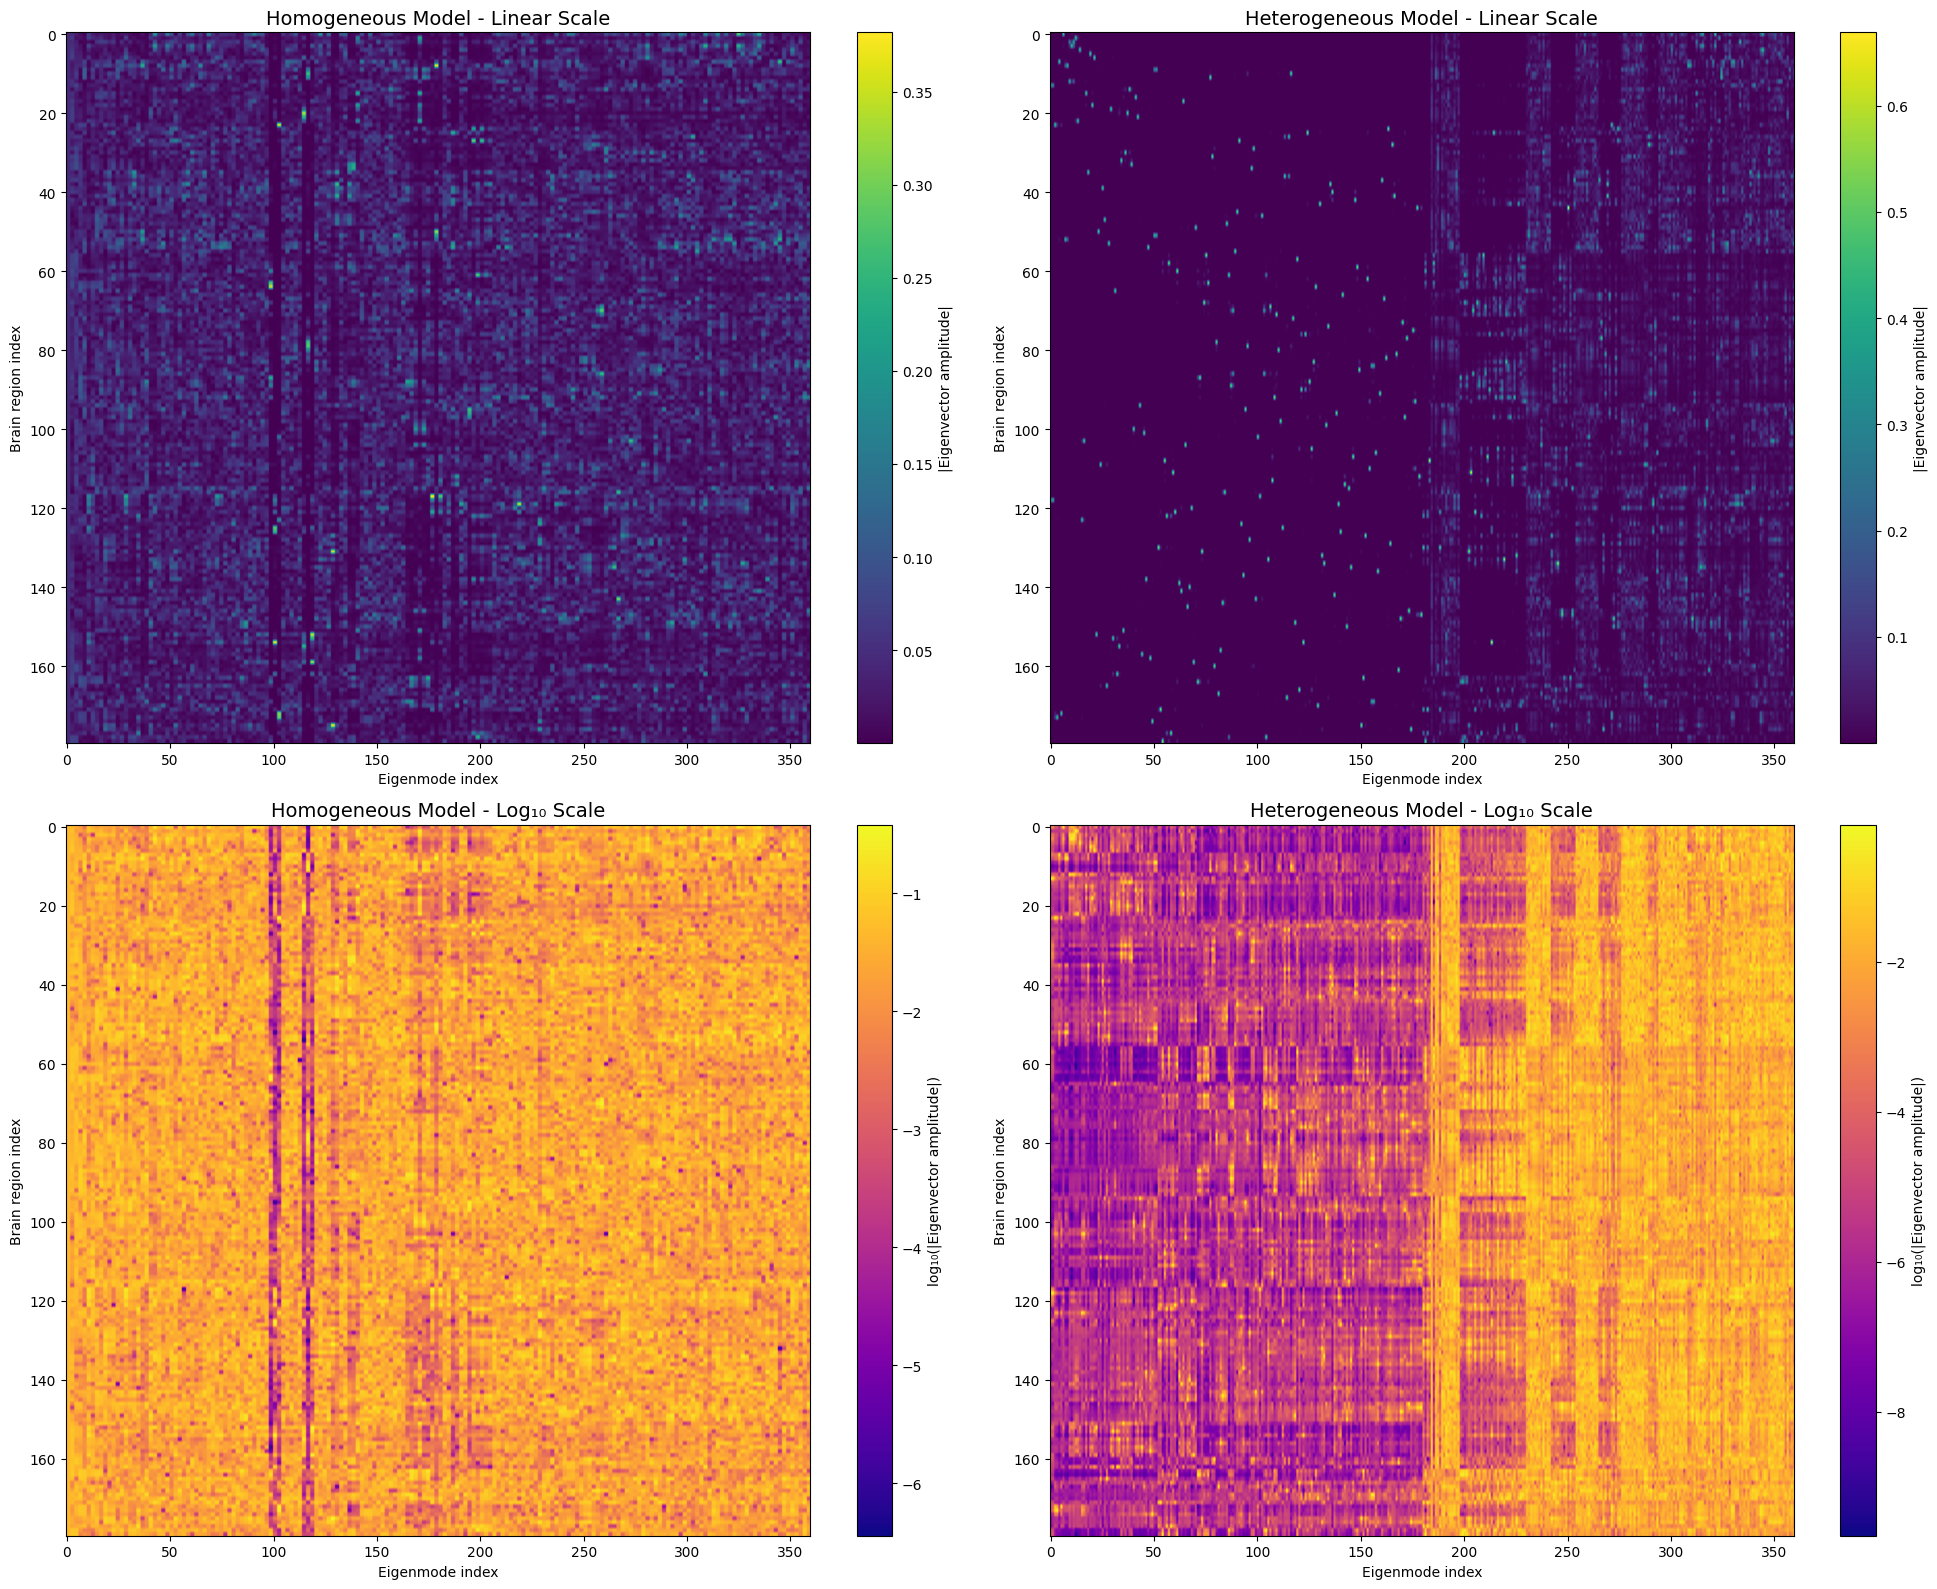

Enhanced visualization with logarithmic scaling reveals fine-scale structure


In [10]:
# ============================================================================
# ENHANCED VISUALIZATION - LOGARITHMIC SCALING
# ============================================================================

# Create enhanced visualizations with logarithmic scaling
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Add small epsilon to avoid log(0)
epsilon = 1e-10

# Top row: Linear scale (original)
im1 = axes[0,0].imshow(np.abs(eigenvectors_excitatory_homo), cmap='viridis', aspect='auto')
axes[0,0].set_title('Homogeneous Model - Linear Scale', fontsize=14)
axes[0,0].set_xlabel('Eigenmode index')
axes[0,0].set_ylabel('Brain region index')
plt.colorbar(im1, ax=axes[0,0], label='|Eigenvector amplitude|')

im2 = axes[0,1].imshow(np.abs(eigenvectors_excitatory_hetero), cmap='viridis', aspect='auto')
axes[0,1].set_title('Heterogeneous Model - Linear Scale', fontsize=14)
axes[0,1].set_xlabel('Eigenmode index')
axes[0,1].set_ylabel('Brain region index')
plt.colorbar(im2, ax=axes[0,1], label='|Eigenvector amplitude|')

# Bottom row: Logarithmic scale
log_homo = np.log10(np.abs(eigenvectors_excitatory_homo) + epsilon)
log_hetero = np.log10(np.abs(eigenvectors_excitatory_hetero) + epsilon)

im3 = axes[1,0].imshow(log_homo, cmap='plasma', aspect='auto')
axes[1,0].set_title('Homogeneous Model - Log₁₀ Scale', fontsize=14)
axes[1,0].set_xlabel('Eigenmode index')
axes[1,0].set_ylabel('Brain region index')
plt.colorbar(im3, ax=axes[1,0], label='log₁₀(|Eigenvector amplitude|)')

im4 = axes[1,1].imshow(log_hetero, cmap='plasma', aspect='auto')
axes[1,1].set_title('Heterogeneous Model - Log₁₀ Scale', fontsize=14)
axes[1,1].set_xlabel('Eigenmode index')
axes[1,1].set_ylabel('Brain region index')
plt.colorbar(im4, ax=axes[1,1], label='log₁₀(|Eigenvector amplitude|)')

plt.tight_layout()
plt.show()

print("Enhanced visualization with logarithmic scaling reveals fine-scale structure")


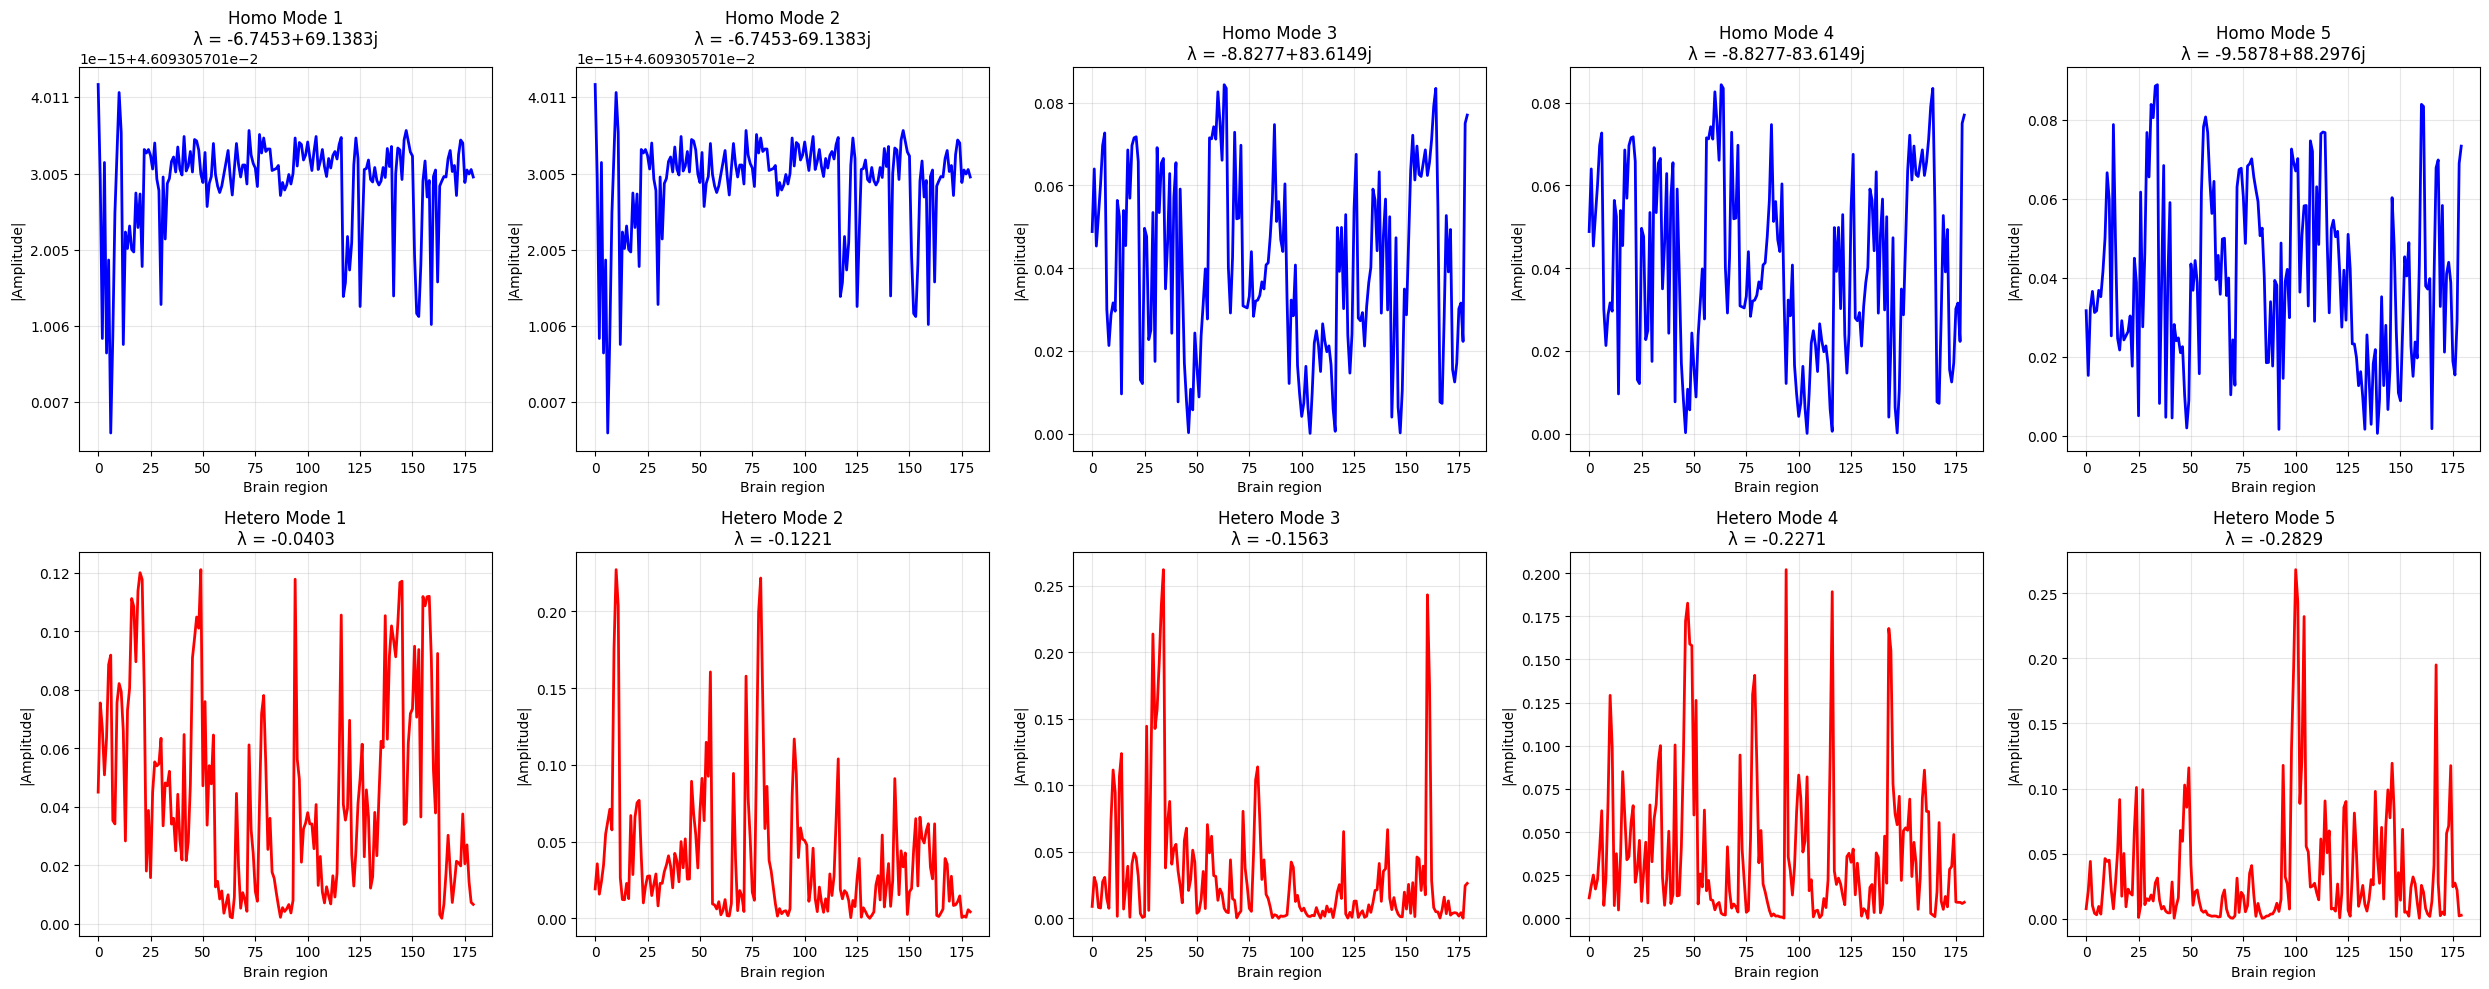

Showing top 5 dominant eigenmodes for each model


In [11]:
# ============================================================================
# DOMINANT EIGENMODES VISUALIZATION
# ============================================================================

# Sort eigenvalues by real part (most unstable/dominant first)
homo_real_parts = eigen_results_homo['real_parts']
hetero_real_parts = eigen_results_hetero['real_parts']

homo_sorted_idx = np.argsort(homo_real_parts)[::-1]  # Descending order
hetero_sorted_idx = np.argsort(hetero_real_parts)[::-1]  # Descending order

# Plot the top 10 most dominant eigenmodes for each model
n_modes_to_show = min(10, eigenvectors_excitatory_homo.shape[1])

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

# Homogeneous model - top 5 modes
for i in range(5):
    mode_idx = homo_sorted_idx[i]
    eigenval = eigen_results_homo['eigenvalues'][mode_idx]
    eigenvec = eigenvectors_excitatory_homo[:, mode_idx]
    
    axes[i].plot(np.abs(eigenvec), 'b-', linewidth=2)
    axes[i].set_title(f'Homo Mode {i+1}\nλ = {eigenval:.4f}', fontsize=12)
    axes[i].set_xlabel('Brain region')
    axes[i].set_ylabel('|Amplitude|')
    axes[i].grid(True, alpha=0.3)

# Heterogeneous model - top 5 modes
for i in range(5):
    mode_idx = hetero_sorted_idx[i]
    eigenval = eigen_results_hetero['eigenvalues'][mode_idx]
    eigenvec = eigenvectors_excitatory_hetero[:, mode_idx]
    
    axes[i+5].plot(np.abs(eigenvec), 'r-', linewidth=2)
    axes[i+5].set_title(f'Hetero Mode {i+1}\nλ = {eigenval:.4f}', fontsize=12)
    axes[i+5].set_xlabel('Brain region')
    axes[i+5].set_ylabel('|Amplitude|')
    axes[i+5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Showing top {5} dominant eigenmodes for each model")


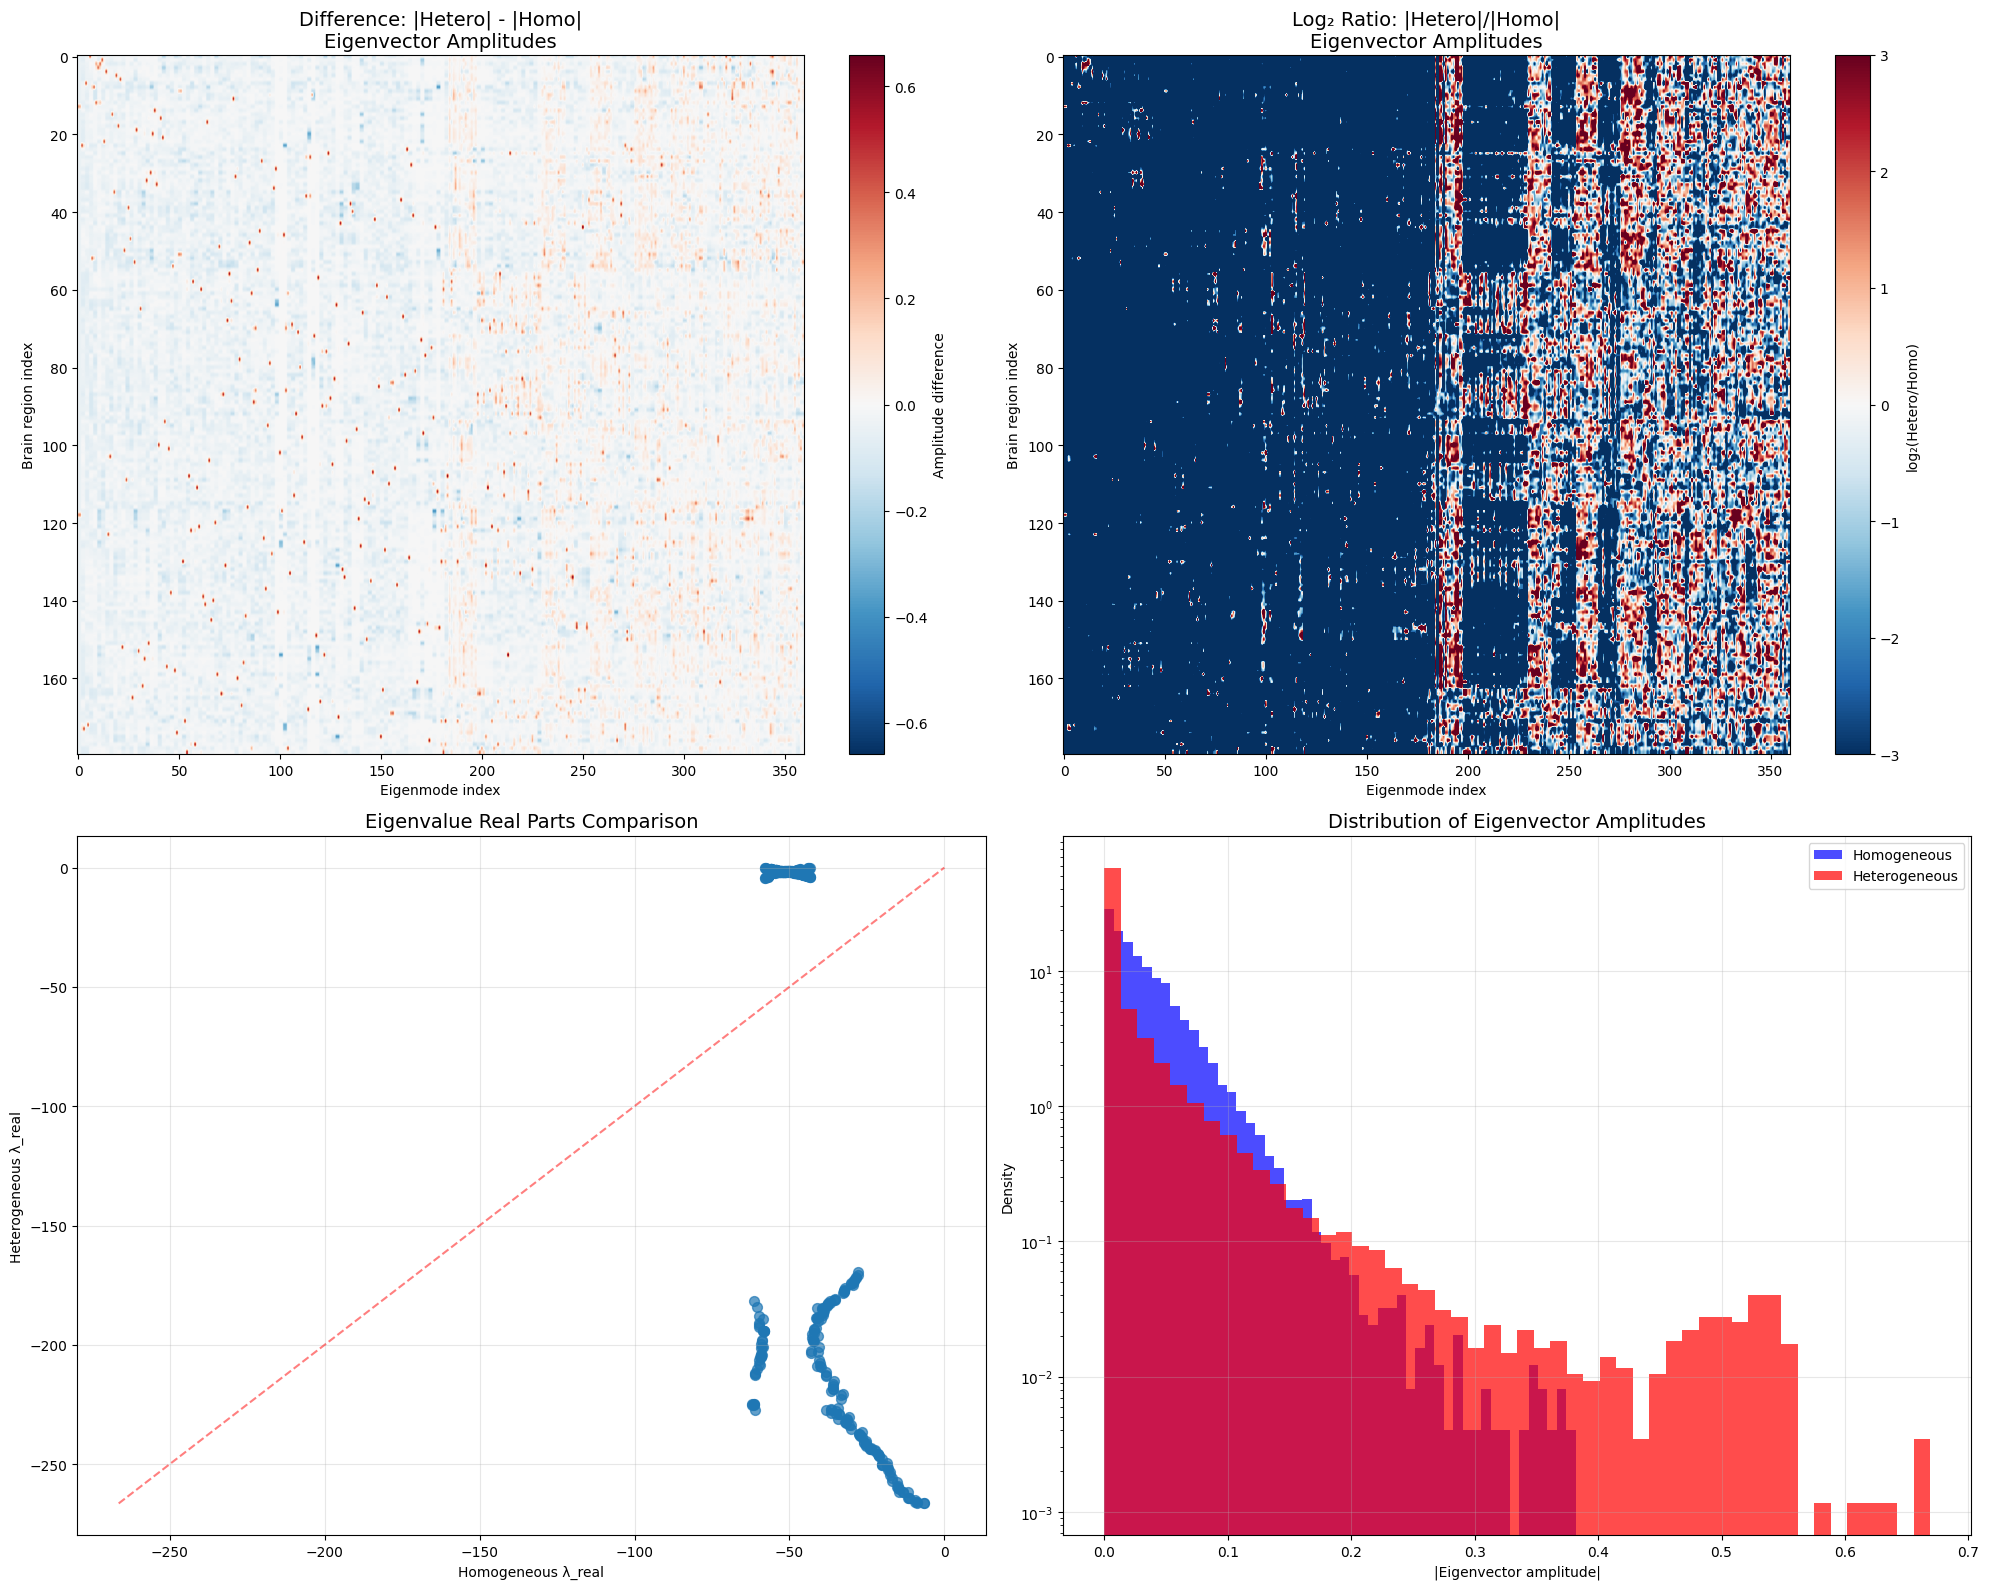

=== STATISTICAL COMPARISON ===
Mean absolute difference: 0.035844
Max absolute difference: 0.658993
RMS difference: 0.057960
Correlation coefficient: 0.015304
Homo eigenvalues range: [-62.131747, -6.745305]
Hetero eigenvalues range: [-266.443047, -0.040321]


In [12]:
# ============================================================================
# STATISTICAL COMPARISON AND HEATMAP DIFFERENCES
# ============================================================================

# Compute difference between models
eigenvec_diff = np.abs(eigenvectors_excitatory_hetero) - np.abs(eigenvectors_excitatory_homo)

# Create comprehensive statistical comparison
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Difference heatmap
im1 = axes[0,0].imshow(eigenvec_diff, cmap='RdBu_r', aspect='auto', 
                       vmin=-np.max(np.abs(eigenvec_diff)), vmax=np.max(np.abs(eigenvec_diff)))
axes[0,0].set_title('Difference: |Hetero| - |Homo|\nEigenvector Amplitudes', fontsize=14)
axes[0,0].set_xlabel('Eigenmode index')
axes[0,0].set_ylabel('Brain region index')
plt.colorbar(im1, ax=axes[0,0], label='Amplitude difference')

# 2. Ratio heatmap (log scale)
ratio_matrix = (np.abs(eigenvectors_excitatory_hetero) + epsilon) / (np.abs(eigenvectors_excitatory_homo) + epsilon)
log_ratio = np.log2(ratio_matrix)

im2 = axes[0,1].imshow(log_ratio, cmap='RdBu_r', aspect='auto', 
                       vmin=-3, vmax=3)  # Limit to ±3 for better visualization
axes[0,1].set_title('Log₂ Ratio: |Hetero|/|Homo|\nEigenvector Amplitudes', fontsize=14)
axes[0,1].set_xlabel('Eigenmode index')
axes[0,1].set_ylabel('Brain region index')
plt.colorbar(im2, ax=axes[0,1], label='log₂(Hetero/Homo)')

# 3. Eigenvalue comparison
axes[1,0].scatter(homo_real_parts, hetero_real_parts, alpha=0.7, s=50)
axes[1,0].plot([min(homo_real_parts.min(), hetero_real_parts.min()),
                max(homo_real_parts.max(), hetero_real_parts.max())],
               [min(homo_real_parts.min(), hetero_real_parts.min()),
                max(homo_real_parts.max(), hetero_real_parts.max())], 'r--', alpha=0.5)
axes[1,0].set_xlabel('Homogeneous λ_real')
axes[1,0].set_ylabel('Heterogeneous λ_real')
axes[1,0].set_title('Eigenvalue Real Parts Comparison', fontsize=14)
axes[1,0].grid(True, alpha=0.3)

# 4. Distribution of eigenmode amplitudes
homo_amplitudes = np.abs(eigenvectors_excitatory_homo).flatten()
hetero_amplitudes = np.abs(eigenvectors_excitatory_hetero).flatten()

axes[1,1].hist(homo_amplitudes, bins=50, alpha=0.7, label='Homogeneous', density=True, color='blue')
axes[1,1].hist(hetero_amplitudes, bins=50, alpha=0.7, label='Heterogeneous', density=True, color='red')
axes[1,1].set_xlabel('|Eigenvector amplitude|')
axes[1,1].set_ylabel('Density')
axes[1,1].set_title('Distribution of Eigenvector Amplitudes', fontsize=14)
axes[1,1].legend()
axes[1,1].set_yscale('log')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistical summary
print("=== STATISTICAL COMPARISON ===")
print(f"Mean absolute difference: {np.mean(np.abs(eigenvec_diff)):.6f}")
print(f"Max absolute difference: {np.max(np.abs(eigenvec_diff)):.6f}")
print(f"RMS difference: {np.sqrt(np.mean(eigenvec_diff**2)):.6f}")
print(f"Correlation coefficient: {np.corrcoef(homo_amplitudes, hetero_amplitudes)[0,1]:.6f}")
print(f"Homo eigenvalues range: [{homo_real_parts.min():.6f}, {homo_real_parts.max():.6f}]")
print(f"Hetero eigenvalues range: [{hetero_real_parts.min():.6f}, {hetero_real_parts.max():.6f}]")
